### Inversion 

In [1]:
# Import necessary dependencies
import glob
import os
import sys
import numpy as np
np.Inf = np.inf 

import pickle
import matplotlib.pyplot as plt
import dask
from dask.diagnostics import ProgressBar
from tqdm import tqdm
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d

from matplotlib import cm
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

from evodcinv import EarthModel, Layer, Curve
from disba import PhaseDispersion
from disba import depthplot

sys.path.append('..')
from src.plot import plot_scatter_section
from src.inv import *

from IPython.display import HTML

import matplotlib as mpl
mpl.rcParams["animation.html"] = "jshtml"
mpl.rcParams["animation.embed_limit"] = 100.0 

#### 1. Load and QC Inversion Inputs

In [2]:
# 1. Define the directory where you saved the files
input_dir = "../results/inv_inputs"
inv_files = sorted(glob.glob(os.path.join(input_dir, "dispersion_*.txt")))

# Master lists to hold the loaded data
x_loaded = []
y_loaded = []
z_loaded = []

# 2. Loop through and load each file
for fpath in inv_files:
    fname = os.path.basename(fpath)
    
    # Extract the distance from the filename (e.g., "dispersion_0120m.txt" -> 120)
    try:
        # Split by '_' and remove 'm.txt' to get just the number
        dist_str = fname.split('_')[1].replace('m.txt', '')
        distance_m = float(dist_str)
    except (IndexError, ValueError):
        print(f"Skipping {fname}: could not parse distance.")
        continue
        
    # Load the 2-column text file, automatically ignoring the '#' header line
    # If using tab-delimited, np.loadtxt handles it natively
    data = np.loadtxt(fpath, comments='#')
    
    # Check if data was loaded correctly (requires at least 1 row)
    if data.ndim != 2 or data.shape[1] != 2:
        print(f"Warning: {fname} does not have the expected 2-column format.")
        continue
        
    f = data[:, 0]  # First column is Frequency
    v = data[:, 1]  # Second column is Phase Velocity
    
    # Append to master lists for mapping
    x_loaded.extend([distance_m] * len(f))
    y_loaded.extend(f)
    z_loaded.extend(v)

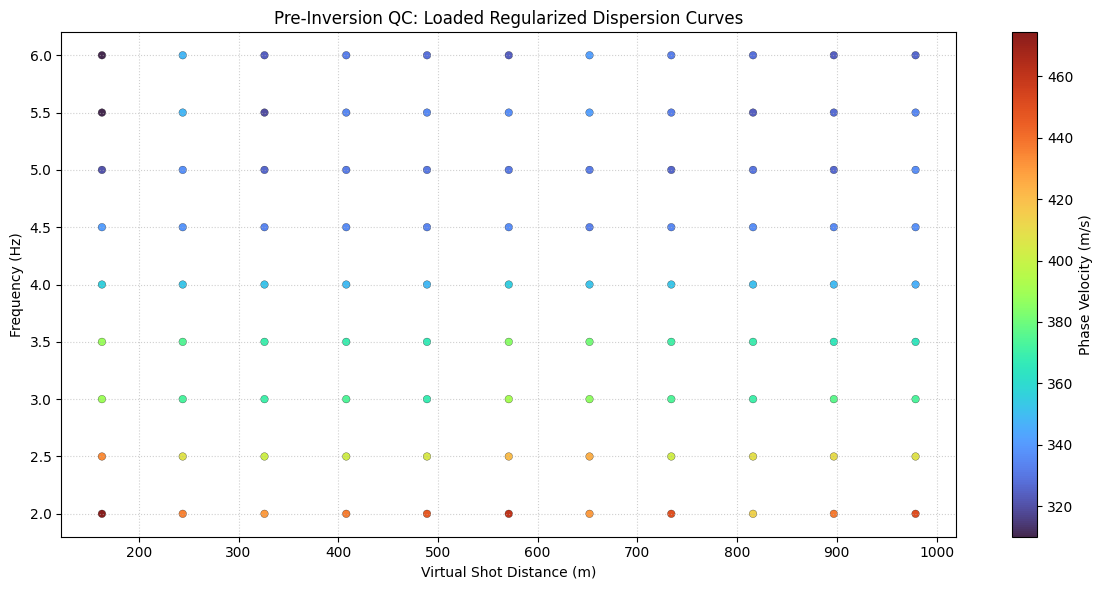

In [3]:
plot_scatter_section(x_loaded, y_loaded, z_loaded, title="Pre-Inversion QC: Loaded Regularized Dispersion Curves")

#### 2. Single-Station 1D Depth Inversion Test

Before we invert the entire DAS array, we need to parameterize our geological model and test our optimizer settings on a single virtual shot. 

In this step, we will:
1. **Load a single dispersion curve:** Read one of our exported `.txt` files.

2. **Convert Units:** `evodcinv` strictly requires **Period (seconds)** instead of Frequency (Hz), and **Phase Velocity in km/s** instead of m/s. It also requires the arrays to be sorted with the period in ascending order.

3. **Initialize the EarthModel:** We define the prior search boundaries for our geological layers (Thickness, S-wave velocity, and Poisson's ratio).

4. **Configure the Optimizer:** We set up the Particle Swarm Optimization (`cpso`), enforce an increasing velocity with depth to stabilize the inversion, and fix the density.

5. **Run & Visualize:** We execute the inversion and plot the resulting 1D shear-wave velocity ($V_s$) profile alongside the predicted vs. observed dispersion curve.

When we define a layer using `model.add(Layer([d_min, d_max], [vs_min, vs_max], [nu_min, nu_max]))`, we are setting the Prior Search Boundaries for the Particle Swarm Optimizer.

Example: `model.add(Layer([0.005, 0.020], [0.10, 0.40], [0.32, 0.34]))`

- Argument 1: `[0.005, 0.020]` (Thickness in km): The algorithm is allowed to guess any thickness for this specific layer between 5 meters and 20 meters.

- Argument 2: `[0.10, 0.40]` (Shear Velocity $V_s$ in km/s): The algorithm can guess any velocity for this layer between 100 m/s and 400 m/s.

- Argument 3: `[0.32, 0.34]` (Poisson's Ratio, unitless): Constrains the $V_p/V_s$ relationship. We keep this tight because surface waves are primarily sensitive to $V_s$, not Poisson's ratio.

In [4]:
# 1. Load and Prepare the Data
test_file = "../results/inv_inputs/dispersion_0163m.txt"
data = np.loadtxt(test_file, comments='#')

f_obs = data[:, 0]      # Frequency in Hz
v_obs_ms = data[:, 1]   # Velocity in m/s

# `evodcinv` requires Period (ascending order) and Velocity (km/s)
# Reversing the arrays [::-1] ensures period goes from low to high
disp_period = 1.0 / f_obs[::-1]  
disp_velocity = v_obs_ms[::-1] / 1000.0

# Define the curve object (Mode 0, Rayleigh wave)
curves = [Curve(disp_period, disp_velocity, mode=0)]

# 2. Build Model Search Boundaries
model = EarthModel()

# Add layers from top to bottom
# Arguments: [Thickness bounds in km], [Vs bounds in km/s], [Poisson's ratio bounds]
# Here we use ~50m thick layers, searching for Vs between 100 - 1000 m/s.

# Layer 1 (Surface soil): Thickness between 5m and 20m
# Cumulative Max Depth: 20m
model.add(Layer([0.005, 0.020], [0.10, 0.40], [0.32, 0.34]))

# Layer 2 (Intermediate 1): Thickness between 10m and 30m
# Cumulative Max Depth: 20m + 30m = 50m
model.add(Layer([0.010, 0.030], [0.20, 0.50], [0.32, 0.34]))

# Layer 3 (Intermediate 2): Thickness between 10m and 35m
# Cumulative Max Depth: 50m + 35m = 85m
model.add(Layer([0.010, 0.035], [0.30, 0.60], [0.32, 0.34]))

# Layer 4 (Intermediate 3): Thickness between 15m and 35m
# Cumulative Max Depth: 85m + 35m = 120m
model.add(Layer([0.015, 0.035], [0.40, 0.70], [0.32, 0.34]))

# Layer 5 (Half-space/Bedrock starts somewhere between 40m and 120m)
# The thickness parameter here is required for syntax but acts as infinite depth.
model.add(Layer([0.050, 0.100], [0.60, 0.85], [0.32, 0.34]))

# 3. Configure the Optimizer
# Fix density to 1.0 g/cm^3 across all layers
f_rho = lambda x: 1.0 + 0.0 * x

model.configure(
    optimizer="cpso",           # Particle Swarm Optimization
    misfit="rmse",              # Root Mean Square Error
    density=f_rho,              # Apply fixed density
    increasing_velocity=True,   # Enforce no low-velocity zones (geological constraint)
    optimizer_args={
        "popsize": 20,          # Number of models per generation
        "maxiter": 1500,        # Maximum iterations per run
        "workers": -1,          # Use all available CPU cores
        "seed": 42,             # For reproducibility
    },
)

print("EarthModel and Optimizer configured successfully.")

EarthModel and Optimizer configured successfully.


#### 3. Run Inversion and Evaluate Results

Now we execute the inversion. Because evolutionary algorithms rely on random sampling, we run the inversion multiple times (`maxrun=5`) to ensure the solution converges on the global minimum rather than getting stuck in a local minimum.

After the inversion completes, we will visualize three things:
1. **Convergence Curve:** How the misfit drops over iterations.

2. **1D Velocity Profile:** The inverted $V_s$ vs. Depth.

3. **Curve Fitting:** How well our modeled dispersion curve matches the actual DAS observations.

In [5]:
# Rnn the inversion
print("Starting inversion... this may take a moment.")
res = model.invert(curves, maxrun=5)
print(res)

Run 1   |▏                   |   0% [0:00:00 / 0:00:22] - Misfit: 0.0076

Starting inversion... this may take a moment.


Run 1   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0058
Run 2   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0058
Run 3   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0058
Run 4   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0058
Run 5   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0058


--------------------------------------------------------------------------------
Best model out of 150000 models (5 runs)

Velocity model                                    Model parameters
----------------------------------------          ------------------------------
         d        vp        vs       rho                   d        vs        nu
      [km]    [km/s]    [km/s]   [g/cm3]                [km]    [km/s]       [-]
----------------------------------------          ------------------------------
    0.0103    0.6153    0.3030    1.0000              0.0103    0.3030    0.3400
    0.0178    0.6153    0.3030    1.0000              0.0178    0.3030    0.3400
    0.0350    0.9442    0.4649    1.0000              0.0350    0.4649    0.3400
    0.0282    0.9184    0.4649    1.0000              0.0282    0.4649    0.3277
    1.0000    1.2874    0.6624    1.0000                   -    0.6624    0.3200
----------------------------------------          ------------------------------


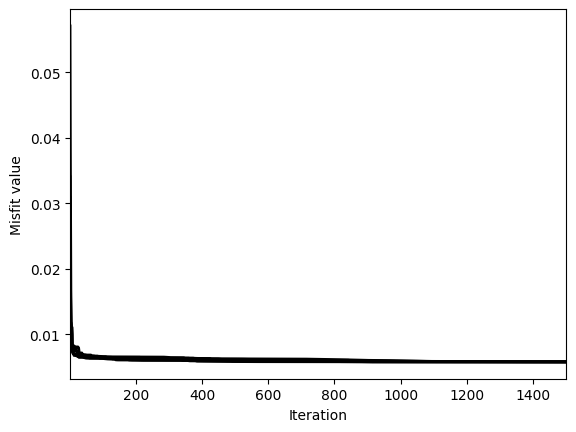

In [6]:
# Misfit convergence (built-in to evodcinv)
res.plot_misfit()
plt.show()

In [7]:
# Print statistics for the top 10% of models
print("\n--- Statistics for Top 10% of Models ---")
model_param_range(res, percent=10)


--- Statistics for Top 10% of Models ---
Evaluating 5 models from the ensemble.
--- Layer 0 ---
Thickness [km] : 0.0103, 0.0103, 0.0140, 0.0140, 0.0140
Vs [km/s]      : 0.3030, 0.3030, 0.3033, 0.3034, 0.3034
Poisson (Nu)   : 0.3368, 0.3368, 0.3370, 0.3400, 0.3400

--- Layer 1 ---
Thickness [km] : 0.0140, 0.0141, 0.0141, 0.0178, 0.0178
Vs [km/s]      : 0.3030, 0.3030, 0.3033, 0.3034, 0.3034
Poisson (Nu)   : 0.3200, 0.3200, 0.3200, 0.3400, 0.3400

--- Layer 2 ---
Thickness [km] : 0.0282, 0.0291, 0.0291, 0.0350, 0.0350
Vs [km/s]      : 0.4649, 0.4649, 0.4680, 0.4685, 0.4685
Poisson (Nu)   : 0.3338, 0.3391, 0.3398, 0.3400, 0.3400

--- Layer 3 ---
Thickness [km] : 0.0282, 0.0282, 0.0350, 0.0350, 0.0350
Vs [km/s]      : 0.4649, 0.4649, 0.4682, 0.4685, 0.4685
Poisson (Nu)   : 0.3277, 0.3277, 0.3279, 0.3279, 0.3280

--- Layer 4 ---
Vs [km/s]      : 0.6624, 0.6624, 0.6636, 0.6663, 0.6664
Poisson (Nu)   : 0.3200, 0.3200, 0.3270, 0.3270, 0.3270



#### 4. Plot the Inverted 1D Velocity Model

Plotting depth profiles for 15001 models.


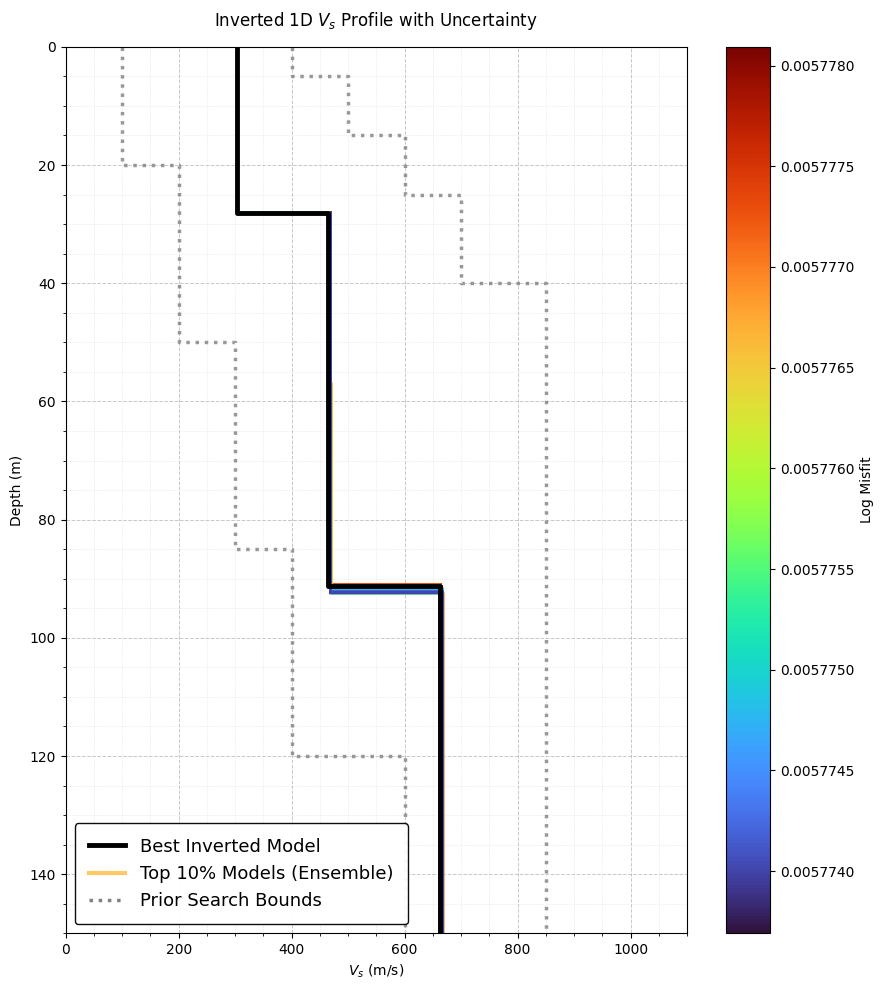

In [8]:
# 1. Make the figure taller and wider
fig, ax = plt.subplots(figsize=(9, 10))

# 2. Add major AND minor grids for easier depth/velocity reading
ax.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.4)
ax.minorticks_on()

# A. Plot the Search Boundaries (Prior)
plot_model_range(
    model, 
    plot_args={"color": "gray", "linestyle": ":", "linewidth": 2.5, "alpha": 0.8}, 
    ax=ax
)

# B. Plot the Ensemble of Top Models (Posterior Uncertainty)
plot_model(
    res, parameter="vs", show="percentage", percent=10, zmax=150, 
    cmap_on=True, plot_args={"cmap": "turbo", "alpha": 0.4}, ax=ax
)

# C. Plot the Single Best Model on top (thicker line for emphasis)
plot_model(
    res, parameter="vs", show="best", zmax=150, 
    plot_args={"color": "black", "linewidth": 3.5, "linestyle": "-"}, ax=ax
)

# 3. Enhanced Typography
ax.set_title("Inverted 1D $V_s$ Profile with Uncertainty", pad=15)
ax.set_xlabel("$V_s$ (m/s)")
ax.set_ylabel("Depth (m)")
ax.tick_params(axis='both', which='major')

# Optional: Add a bit of padding to the x-axis so the bounds don't touch the frame
ax.set_xlim([0, 1100]) 

# 4. Create a Custom Legend
legend_elements = [
    Line2D([0], [0], color='black', lw=3.5, linestyle='-', label='Best Inverted Model'),
    Line2D([0], [0], color='orange', lw=3, alpha=0.6, label='Top 10% Models (Ensemble)'),
    Line2D([0], [0], color='gray', lw=2.5, linestyle=':', label='Prior Search Bounds')
]

ax.legend(
    handles=legend_elements, 
    loc='lower left',        
    fontsize=13, 
    framealpha=0.95,         
    edgecolor='black',
    borderpad=0.8
)

plt.tight_layout()
plt.show()

Plotting curves from 15001 models.


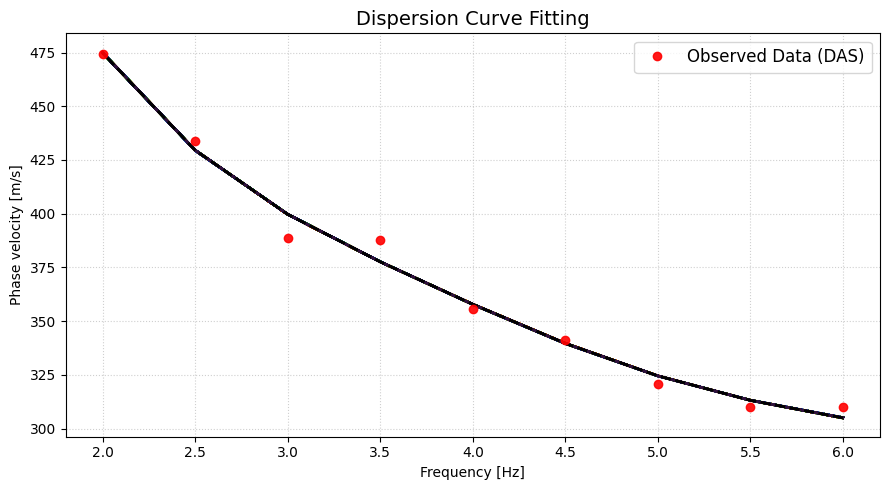

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

# A. Plot the ensemble of theoretical dispersion curves
plot_predicted_curve(
    res, disp_period, mode=0, wave='rayleigh', curve_type='phase', 
    show="percentage", percent=10, 
    plot_args={"xaxis": "frequency", "cmap": "turbo", "alpha": 0.1}, ax=ax
)

# B. Plot the single best theoretical curve
plot_predicted_curve(
    res, disp_period, mode=0, wave='rayleigh', curve_type='phase', 
    show="best", 
    plot_args={"xaxis": "frequency", "color": "black", "linewidth": 2, "linestyle": "--"}, ax=ax
)

# C. Overlay the actual DAS observations
ax.plot(f_obs, v_obs_ms, 'ro', label='Observed Data (DAS)', markersize=6, alpha=0.9)

ax.grid(True, linestyle=':', alpha=0.6)
# Fix legend to avoid duplicate labels from the ensemble
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=12)

ax.set_title("Dispersion Curve Fitting", fontsize=14)
plt.tight_layout()
plt.show()

#### 5. Run Inversion for All Virtual Shots

In [2]:
input_dir = "../results/inv_inputs"
out_dir = "../results/inv_outputs"
os.makedirs(out_dir, exist_ok=True)

# Find all txt files and sort them alphabetically (which sorts them by distance)
file_list = sorted(glob.glob(os.path.join(input_dir, "dispersion_*.txt")))

# Create a regular depth grid from 0 to 120m (1-meter resolution)
max_depth = 120  # Maximum depth in meters
z_grid = np.arange(0, max_depth + 1, 1)  # Depth grid from 0 to 120m with 1m intervals

# Initialize lists to hold the results
positons = []
vs_2d_matrix = []
all_results = []

In [7]:
for i, file_path in enumerate(file_list):
    # Extract the distance from the filename (e.g., "dispersion_0120m.txt" -> 120)
    basename = os.path.basename(file_path)
    distance_str = ''.join(filter(str.isdigit, basename))
    dist = float(distance_str)
    positons.append(dist)

    print(f"Processing {i+1}/{len(file_list)}: Station at {dist}m", end=" ")

    # Load and convert data
    data = np.loadtxt(file_path, comments='#')
    f_obs = data[:, 0]      # Frequency in Hz
    v_obs_ms = data[:, 1]   # Velocity in m/s

    disp_period = 1.0 / f_obs[::-1]
    disp_velocity = v_obs_ms[::-1] / 1000.0
    curves = [Curve(disp_period, disp_velocity, 0, "rayleigh")]

    # Build the same EarthModel for each station
    model = EarthModel()
    model.add(Layer([0.005, 0.020], [0.10, 0.40], [0.32, 0.34])) # Layer 1
    model.add(Layer([0.010, 0.030], [0.20, 0.50], [0.32, 0.34])) # Layer 2
    model.add(Layer([0.010, 0.035], [0.30, 0.60], [0.32, 0.34])) # Layer 3
    model.add(Layer([0.015, 0.035], [0.40, 0.70], [0.32, 0.34])) # Layer 4
    model.add(Layer([0.050, 0.100], [0.45, 0.85], [0.32, 0.34])) # Layer 5 (Half-space)

    model.configure(
        optimizer="cpso",           
        misfit="rmse",              
        density=lambda x: 1.0 + 0.0 * x,              
        increasing_velocity=True,   
        optimizer_args={"popsize": 20, "maxiter": 1500, "workers": -1, "seed": 42}
    )

    # Run the inversion.
    res = model.invert(curves, maxrun=5)
    all_results.append(res)
    print(f"Done. Best Misfit: {res.misfit:.4f}")

    # Pickle the entire result object
    res_filepath = os.path.join(out_dir, f"inv_result_{dist}m.pkl")
    with open(res_filepath, 'wb') as f:
        pickle.dump(res, f)

    # res.model contains [thickness, Vp, Vs, density] in km and km/s
    out_file = os.path.join(out_dir, f"1D_model_{dist}m.txt")
    np.savetxt(out_file, res.model, 
               header="Thickness(km) Vp(km/s) Vs(km/s) Density(g/cm3)", 
               fmt="%.6f")

    # Interpolate 1D Model onto Regular Depth Grid
    thicknesses = res.model[:, 0] * 1000  # Convert thickness from km to m
    vs = res.model[:, 2] * 1000  # Convert Vs from km/s to m/s

    # Convert layer thicknesses to cumulative depth
    depths = np.insert(np.cumsum(thicknesses), 0, 0)
    vs_step = np.insert(vs, 0, vs[0])

    # Interpolate using previous to to keep the blocky geological steps
    f_interp = interp1d(depths, vs_step, kind='previous', fill_value=(vs[0], vs[-1]), bounds_error=False)

    # Sample velocity at 1m grid 
    vs_profile = f_interp(z_grid)
    vs_2d_matrix.append(vs_profile)

# Convert lists to NumPy arrays for plotting 
positions = np.array(positons)
vs_2d_matrix = np.array(vs_2d_matrix).T # Transpose: rows=Depth, columns=Distance

# This saves multiple arrays into a single compressed .npz file
np.savez(os.path.join(out_dir, "final_2D_matrix.npz"), 
         vs_matrix=vs_2d_matrix, 
         positions=positions, 
         z_grid=z_grid)

all_res_filepath = os.path.join(out_dir, "all_results_list.pkl")
with open(all_res_filepath, "wb") as f:
    pickle.dump(all_results, f)
print("Saved all InversionResult objects successfully!")

Run 1   |▏                   |   1% [0:00:00 / 0:00:20] - Misfit: 0.0075

Processing 1/11: Station at 163.0m 

Run 1   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0058
Run 2   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0058
Run 3   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0058
Run 4   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0058
Run 5   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0058
Run 1   |▏                   |   0% [0:00:00 / 0:00:20] - Misfit: 0.0070

Done. Best Misfit: 0.0058
Processing 2/11: Station at 244.0m 

Run 1   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0066
Run 2   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0065
Run 3   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0065
Run 4   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0066
Run 5   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0065
Run 1   |▏                   |   0% [0:00:00 / 0:00:21] - Misfit: 0.0051

...

Done. Best Misfit: 0.0055
Processing 10/11: Station at 897.0m 

Run 1   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0028
Run 2   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0028
Run 3   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0028
Run 4   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0028
Run 5   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0028
Run 1   |▏                   |   0% [0:00:00 / 0:00:22] - Misfit: 0.0059

Done. Best Misfit: 0.0028
Processing 11/11: Station at 979.0m 

Run 1   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0029
Run 2   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0029
Run 3   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0029
Run 4   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0029
Run 5   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0029


Done. Best Misfit: 0.0029
Saved all InversionResult objects successfully!


#### 6. Run Inversion Results

In [3]:
# Load the saved 2D matrix and metadata
saved_data = np.load("../results/inv_outputs/final_2D_matrix.npz")
vs_2d_matrix = saved_data['vs_matrix']
positions = saved_data['positions']
z_grid = saved_data['z_grid']

# Load the entire list of InversionResult objects back into memory
with open("../results/inv_outputs/all_results_list.pkl", "rb") as f:
    all_results = pickle.load(f)

In [ ]:
print("Saving all profile plots to disk...")

for i, res in enumerate(tqdm(all_results)):
    dist = positions[i]
    save_profile_plot(
        res=res, 
        prior_model=model, 
        dist=dist,
        save_dir="../results/inv_profiles"
    )

print("Done saving all images!")

Saving all profile plots to disk...


  0%|          | 0/11 [00:00<?, ?it/s]

Plotting depth profiles for 15001 models.


  9%|▉         | 1/11 [00:49<08:10, 49.03s/it]

Plotting depth profiles for 15001 models.


...

Plotting depth profiles for 15001 models.


 91%|█████████ | 10/11 [07:06<00:40, 40.93s/it]

Plotting depth profiles for 15001 models.


100%|██████████| 11/11 [07:46<00:00, 42.38s/it]

Done saving all images!
